# 04 — Results Analysis

Statistical analysis of the data efficiency experiment results:

- Model ranking table (best fraction → best AUROC)
- DeLong pairwise statistical test on full-dataset results
- ROC curves per model at 100% training data
- Confusion matrix inspection (MES)
- Per-class sensitivity analysis (MES)

Run **after** completing the experiments and reviewing notebooks 01–03.

In [12]:
import sys
from pathlib import Path

ROOT = Path("..")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

from src.evaluation import plot_delong_heatmap
from src.evaluation.delong import delong_matrix
from src.evaluation.plots import plot_roc_curves, plot_confusion_matrix_multiclass

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## Configuration

In [13]:
ULCER_RESULTS = ROOT / "results/ulcer/data_efficiency/results.csv"
ULCER_RAW     = ROOT / "results/ulcer/data_efficiency/results_per_seed.csv"
ULCER_PREDS   = ROOT / "results/ulcer/data_efficiency/predictions"

MES_RESULTS   = ROOT / "results/mes/data_efficiency/results.csv"
MES_RAW       = ROOT / "results/mes/data_efficiency/results_per_seed.csv"
MES_PREDS     = ROOT / "results/mes/data_efficiency/predictions"

# Significance threshold for DeLong test
ALPHA = 0.05

## 1. Load Results

In [14]:
def load_df(path, label):
    if not path.exists():
        print(f"[{label}] Not found: {path}")
        return None
    return pd.read_csv(path)

df_ulcer = load_df(ULCER_RESULTS, "ULCER")
df_mes   = load_df(MES_RESULTS,   "MES")
raw_ulcer = load_df(ULCER_RAW, "ULCER-RAW")
raw_mes   = load_df(MES_RAW,   "MES-RAW")

## 2. Model Ranking Table

In [15]:
def ranking_table(df: pd.DataFrame, task: str, metric: str = "auroc_mean") -> None:
    if df is None:
        return

    # Best row per model = highest metric at any fraction
    idx = df.groupby("model")[metric].idxmax()
    best = df.loc[idx].sort_values(metric, ascending=False)

    display_cols = [c for c in [
        "model", "freeze", "head_type", "pct_data",
        "auroc_mean", "auroc_std", "f1_mean", "f1_std",
        "tuned_sensitivity_mean", "tuned_specificity_mean",
        "clip_auroc_mean",
    ] if c in best.columns]

    print(f"\n{'='*60}\n{task} — model ranking (best fraction)\n{'='*60}")
    display(best[display_cols].reset_index(drop=True).round(4))

ranking_table(df_ulcer, "Ulcer detection")
ranking_table(df_mes,   "MES scoring")


Ulcer detection — model ranking (best fraction)


,model,freeze,head_type,pct_data,auroc_mean,auroc_std,f1_mean,f1_std,tuned_sensitivity_mean,tuned_specificity_mean,clip_auroc_mean
0,vits16_imagenet,finetune,linear,10,0.714,NaN,0.265,NaN,0.4760,0.7895,0.6528
1,efficientnetb0,finetune,linear,10,0.442,NaN,0.287,NaN,0.5066,0.3891,0.3854



MES scoring — model ranking (best fraction)


,model,freeze,head_type,pct_data,auroc_mean,auroc_std,f1_mean,f1_std,clip_auroc_mean
0,vits16_imagenet,finetune,linear,10,0.612,NaN,0.274,NaN,0.746
1,efficientnetb0,finetune,linear,10,0.568,NaN,0.271,NaN,0.529


## 3. Performance at Each Fraction — Heatmap

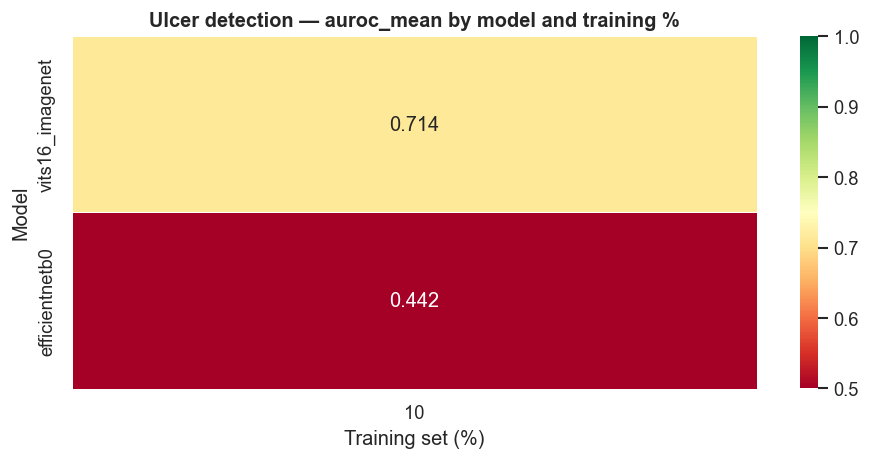

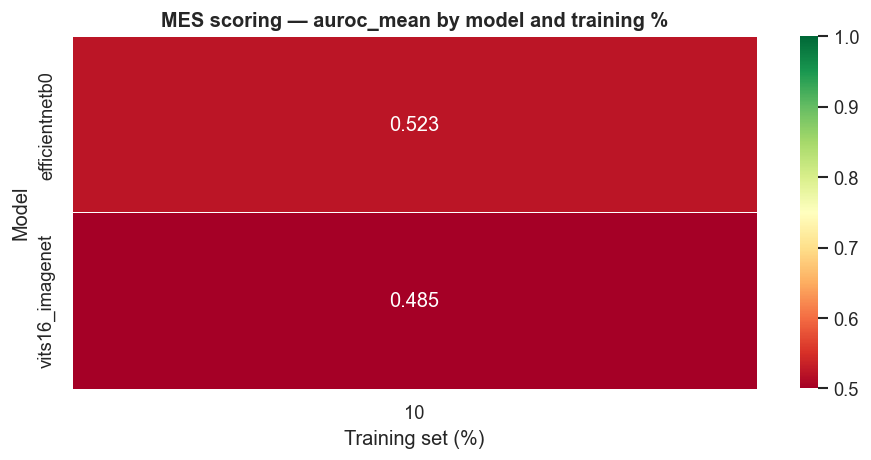

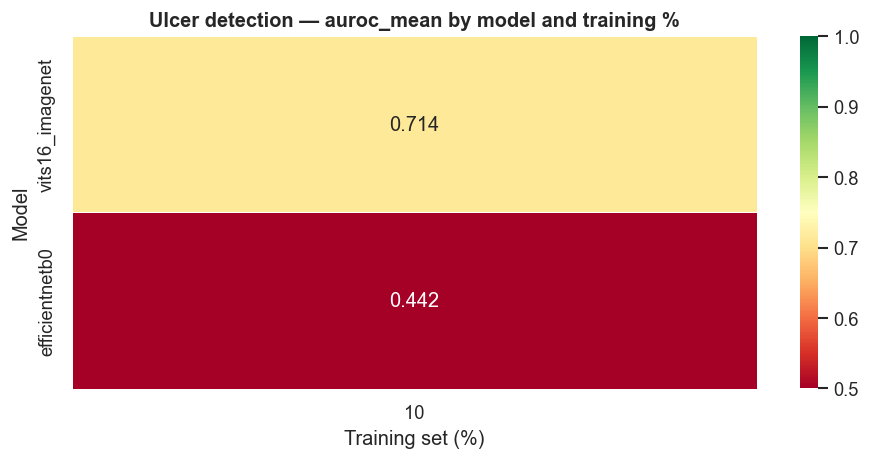

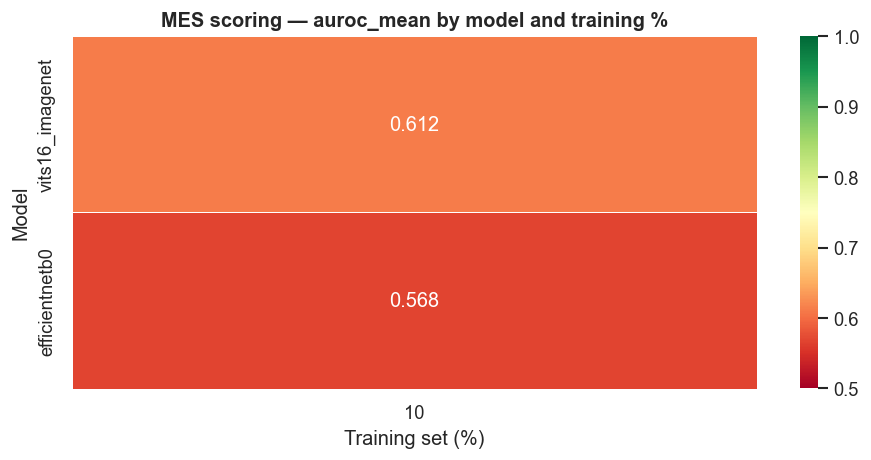

In [16]:
def plot_heatmap(df: pd.DataFrame, task: str, metric: str = "auroc_mean") -> None:
    if df is None or metric not in df.columns:
        return

    pivot = df.pivot_table(index="model", columns="pct_data", values=metric)
    pivot = pivot.sort_values(pivot.columns[-1], ascending=False)

    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 1.2), max(4, len(pivot) * 0.6)))
    sns.heatmap(
        pivot, annot=True, fmt=".3f", cmap="RdYlGn",
        vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5,
    )
    ax.set_title(f"{task} — {metric} by model and training %", fontweight="bold")
    ax.set_xlabel("Training set (%)")
    ax.set_ylabel("Model")
    fig.tight_layout()
    plt.show()

plot_heatmap(df_ulcer, "Ulcer detection")
plot_heatmap(df_mes,   "MES scoring")

In [17]:
%matplotlib inline

## 4. DeLong Pairwise Statistical Test

Compares AUROC scores at the **100% training fraction** across all models.
Requires the saved `.npy` prediction files.

In [18]:
def load_predictions_at_fraction(
    preds_dir: Path,
    df_raw: pd.DataFrame,
    target_pct: int = 100,
    head_filter: str = "linear",
) -> dict[str, dict]:
    """Load saved predictions for the best seed of each model at target_pct."""
    results = {}
    if df_raw is None or not preds_dir.exists():
        return results

    subset = df_raw[
        (df_raw["pct_data"] == target_pct) &
        (df_raw["head_type"] == head_filter)
    ]
    # Best seed per model = highest AUROC
    best = subset.loc[subset.groupby("model")["auroc"].idxmax()]

    for _, row in best.iterrows():
        model_name = row["model"]
        freeze_str = "frozen" if row["freeze"] == "frozen" else "finetune"
        run_name = f"{model_name}_{freeze_str}_{row['head_type']}_{target_pct}pct_seed{int(row['seed'])}"
        run_dir = preds_dir / run_name
        labels_path = run_dir / "test_labels.npy"
        probs_path  = run_dir / "test_probs.npy"
        if not labels_path.exists() or not probs_path.exists():
            print(f"  [Skip] predictions not found for {run_name}")
            continue
        labels = np.load(labels_path)
        probs  = np.load(probs_path)
        if probs.ndim == 2:  # multiclass → take argmax for binary DeLong, or use OVR
            probs = probs.max(axis=1)  # simplified for DeLong
        results[model_name] = {"labels": labels, "probs": probs, "auroc": row["auroc"]}
    return results


print("Loading predictions for DeLong test...")
ulcer_preds = load_predictions_at_fraction(ULCER_PREDS, raw_ulcer)
mes_preds   = load_predictions_at_fraction(MES_PREDS,   raw_mes)
print(f"Ulcer models loaded: {list(ulcer_preds.keys())}")
print(f"MES models loaded:   {list(mes_preds.keys())}")

Loading predictions for DeLong test...
Ulcer models loaded: []
MES models loaded:   []


In [19]:
def run_delong_analysis(preds_dict: dict, task: str, alpha: float = 0.05) -> None:
    if len(preds_dict) < 2:
        print(f"[{task}] Need ≥ 2 models for DeLong test. Found {len(preds_dict)}.")
        return

    # All models must share the same labels
    reference = next(iter(preds_dict))
    labels = preds_dict[reference]["labels"]
    probs_dict = {name: v["probs"] for name, v in preds_dict.items()}

    p_matrix, df_delong = delong_matrix(labels=labels, model_probs=probs_dict, alpha=alpha)

    print(f"\n{'='*60}\n{task} — DeLong pairwise test (α={alpha})\n{'='*60}")
    print(df_delong.to_string(index=False))
    n_sig = int(df_delong["significant"].sum())
    print(f"\n{n_sig}/{len(df_delong)} significant pairs (α={alpha})")

    fig = plot_delong_heatmap(p_matrix, df_delong, alpha=alpha)
    plt.show()

run_delong_analysis(ulcer_preds, "Ulcer detection", ALPHA)
run_delong_analysis(mes_preds,   "MES scoring",     ALPHA)

[Ulcer detection] Need ≥ 2 models for DeLong test. Found 0.
[MES scoring] Need ≥ 2 models for DeLong test. Found 0.


## 5. ROC Curves at 100% Training Data

In [20]:
def plot_roc_all_models(preds_dict: dict, task: str) -> None:
    if not preds_dict:
        return

    roc_data = []
    for model_name, v in preds_dict.items():
        labels = v["labels"]
        probs  = v["probs"]
        # Binary classification: use probs directly
        # Multiclass: use max probability as simplified 1-vs-rest proxy
        if probs.ndim == 2:
            probs = probs.max(axis=1)
        try:
            fpr, tpr, _ = roc_curve(labels, probs)
            auc = roc_auc_score(labels, probs)
            roc_data.append({"name": model_name, "fpr": fpr, "tpr": tpr, "auc": auc})
        except Exception as e:
            print(f"  Could not compute ROC for {model_name}: {e}")

    if roc_data:
        fig = plot_roc_curves(roc_data, title=f"{task} — ROC curves (100% training data)")
        plt.show()

plot_roc_all_models(ulcer_preds, "Ulcer detection")
plot_roc_all_models(mes_preds,   "MES scoring")

## 6. MES Per-Class Sensitivity

In [21]:
def plot_per_class_sensitivity(df: pd.DataFrame, target_pct: int = 100) -> None:
    if df is None:
        return
    sens_cols = [c for c in df.columns if c.startswith("sens_mayo") and c.endswith("_mean")]
    if not sens_cols:
        print("No per-class sensitivity columns found (sens_mayo0_mean, ...).")
        return

    sub = df[df["pct_data"] == target_pct].copy()
    if sub.empty:
        print(f"No results at {target_pct}% training data.")
        return

    sub = sub.sort_values("auroc_mean", ascending=False)
    display_cols = ["model"] + sens_cols
    melt = sub[display_cols].melt(id_vars="model", var_name="class", value_name="sensitivity")
    melt["class"] = melt["class"].str.replace("sens_mayo", "Mayo ").str.replace("_mean", "")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=melt, x="model", y="sensitivity", hue="class", ax=ax)
    ax.set_title(f"MES — per-class sensitivity at {target_pct}% training data", fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel("Sensitivity")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Class", loc="lower right")
    fig.tight_layout()
    plt.show()

plot_per_class_sensitivity(df_mes)

No per-class sensitivity columns found (sens_mayo0_mean, ...).


## 7. Full Summary Export

In [22]:
def export_summary(df: pd.DataFrame, task: str, out_dir: Path) -> None:
    if df is None:
        return
    out_dir.mkdir(parents=True, exist_ok=True)

    # Best model per fraction
    best_per_fraction = (
        df.loc[df.groupby("pct_data")["auroc_mean"].idxmax()]
        [["pct_data", "model", "auroc_mean", "auroc_std", "f1_mean", "f1_std"]]
        .sort_values("pct_data")
    )
    out_path = out_dir / f"{task}_best_per_fraction.csv"
    best_per_fraction.to_csv(out_path, index=False)
    print(f"[{task}] Exported: {out_path}")
    display(best_per_fraction.round(4))

export_summary(df_ulcer, "ulcer", ROOT / "results/ulcer/data_efficiency")
export_summary(df_mes,   "mes",   ROOT / "results/mes/data_efficiency")

[ulcer] Exported: ..\results\ulcer\data_efficiency\ulcer_best_per_fraction.csv


,pct_data,model,auroc_mean,auroc_std,f1_mean,f1_std
1,10,vits16_imagenet,0.714,NaN,0.265,NaN


[mes] Exported: ..\results\mes\data_efficiency\mes_best_per_fraction.csv


,pct_data,model,auroc_mean,auroc_std,f1_mean,f1_std
1,10,vits16_imagenet,0.612,NaN,0.274,NaN
